Reynold1 Phase


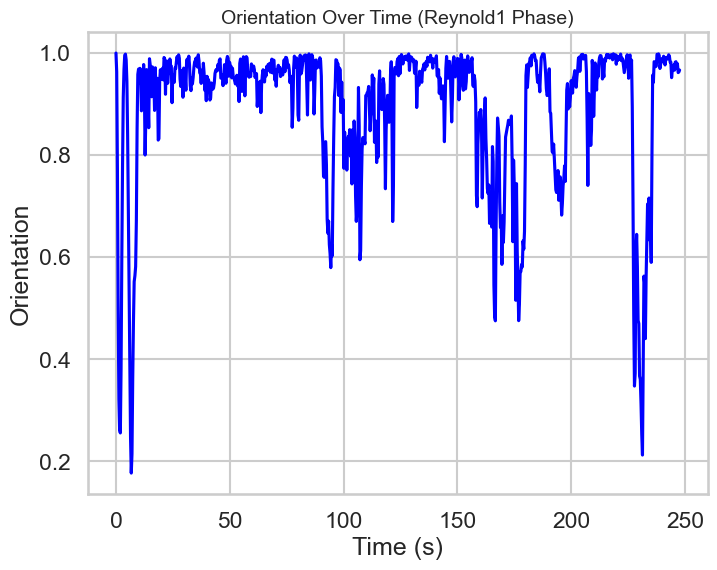

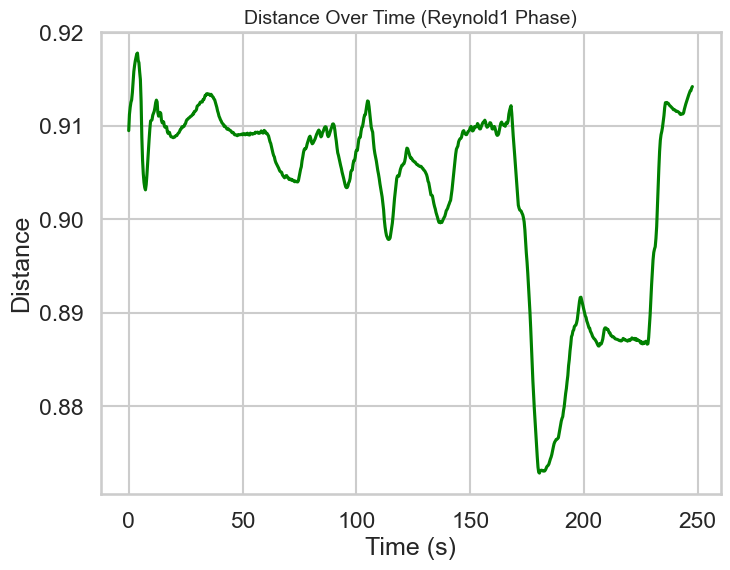

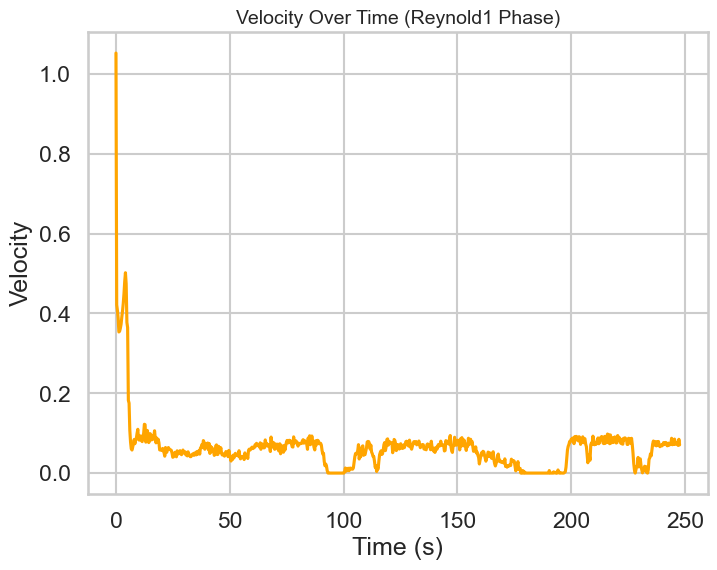

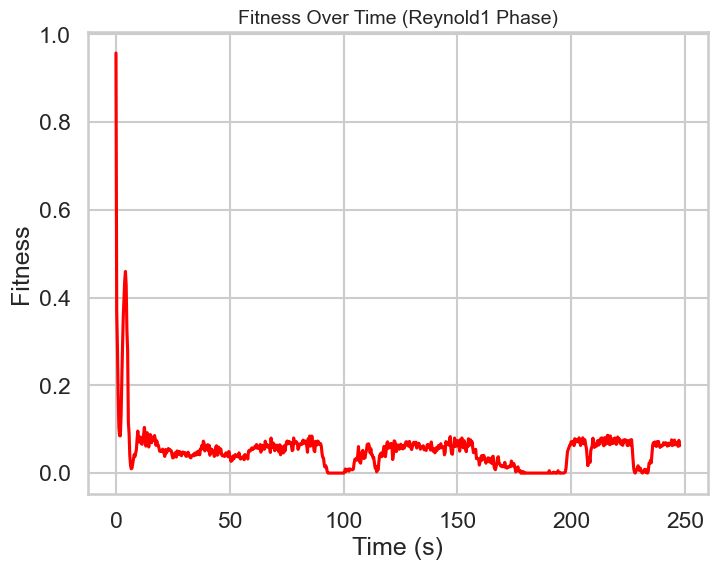

Laplace Phase


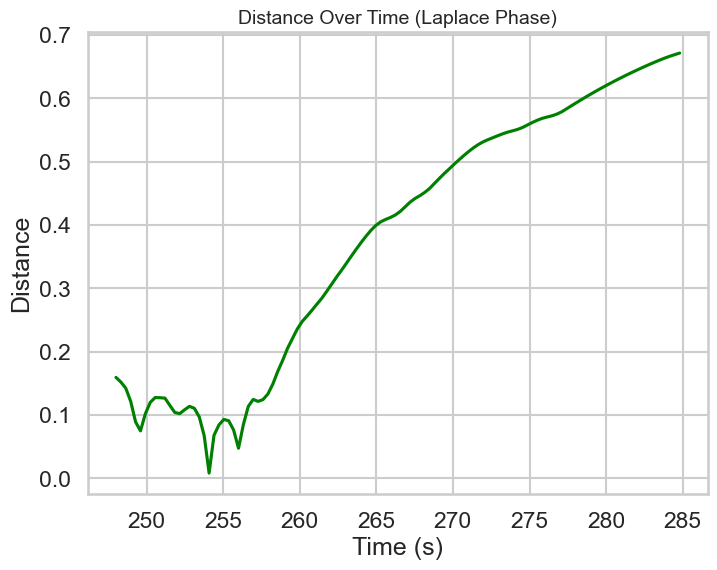

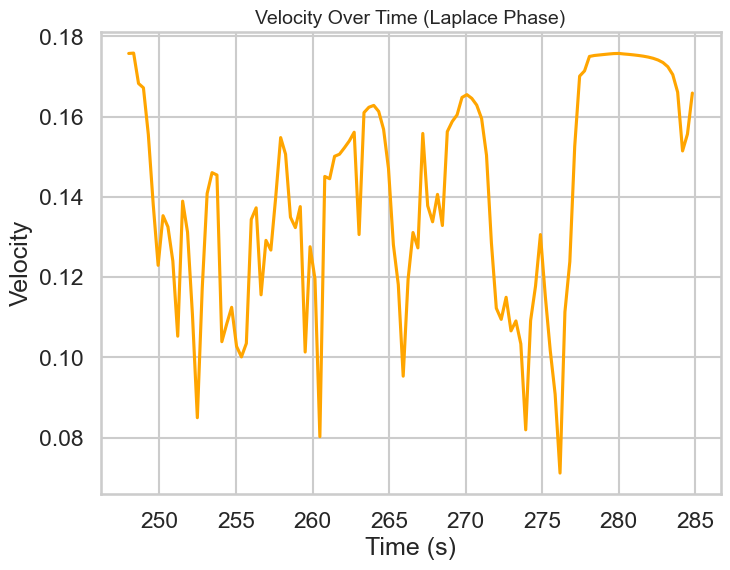

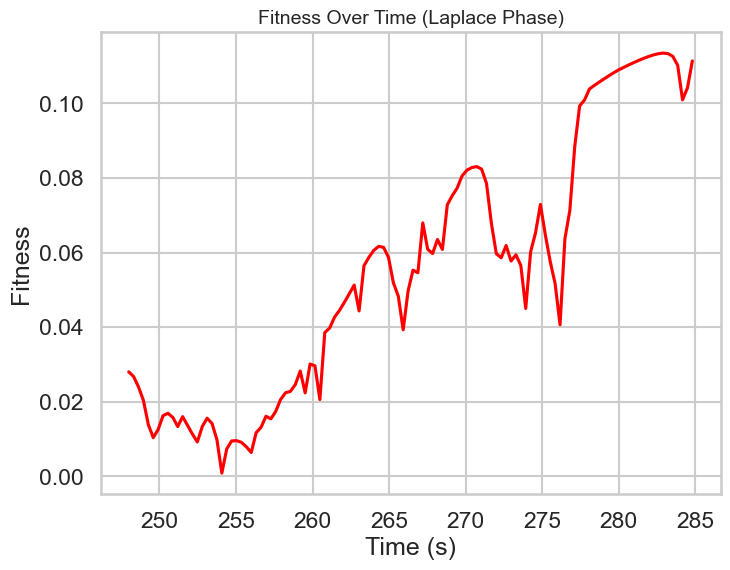

Reynold2 Phase


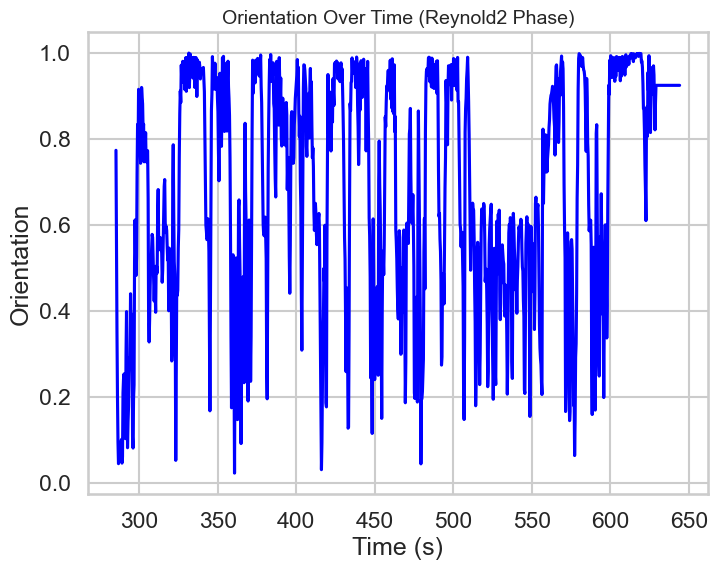

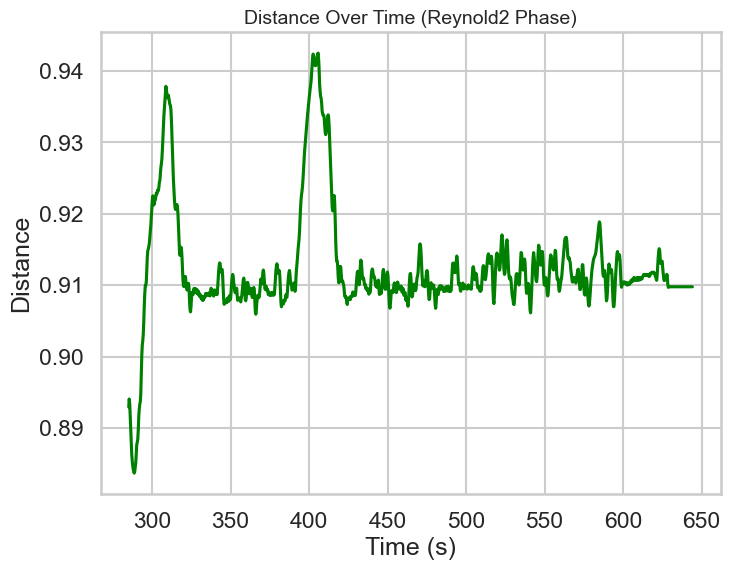

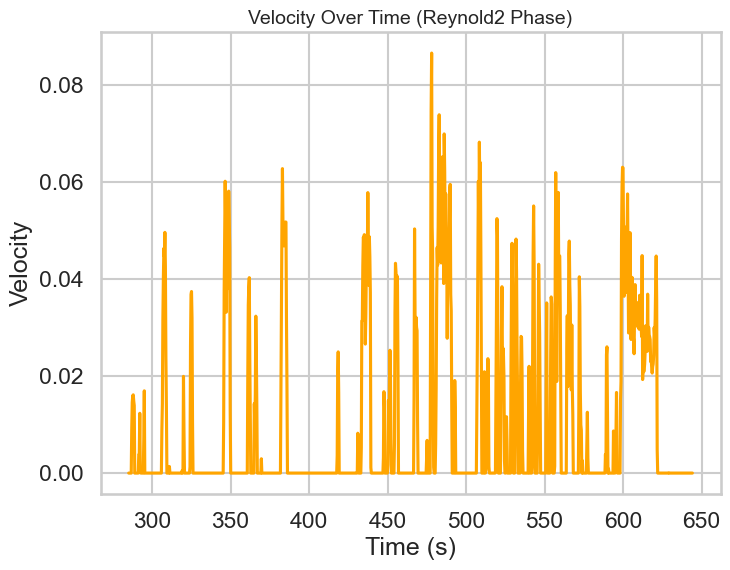

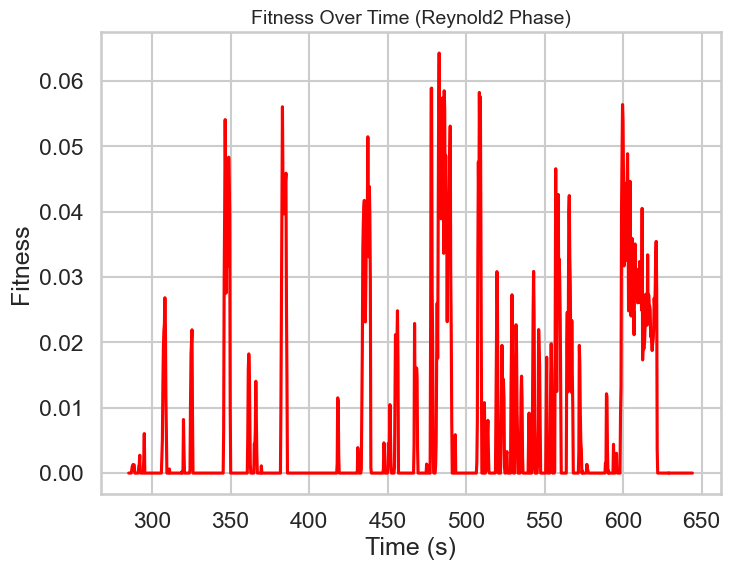

Trajectories


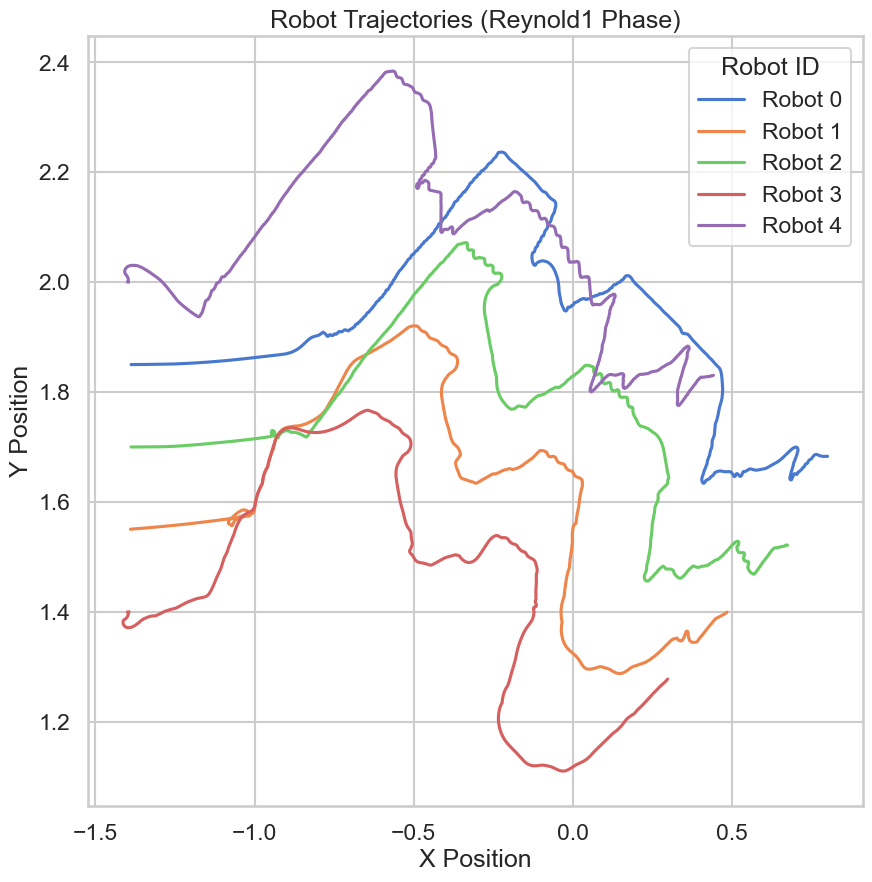

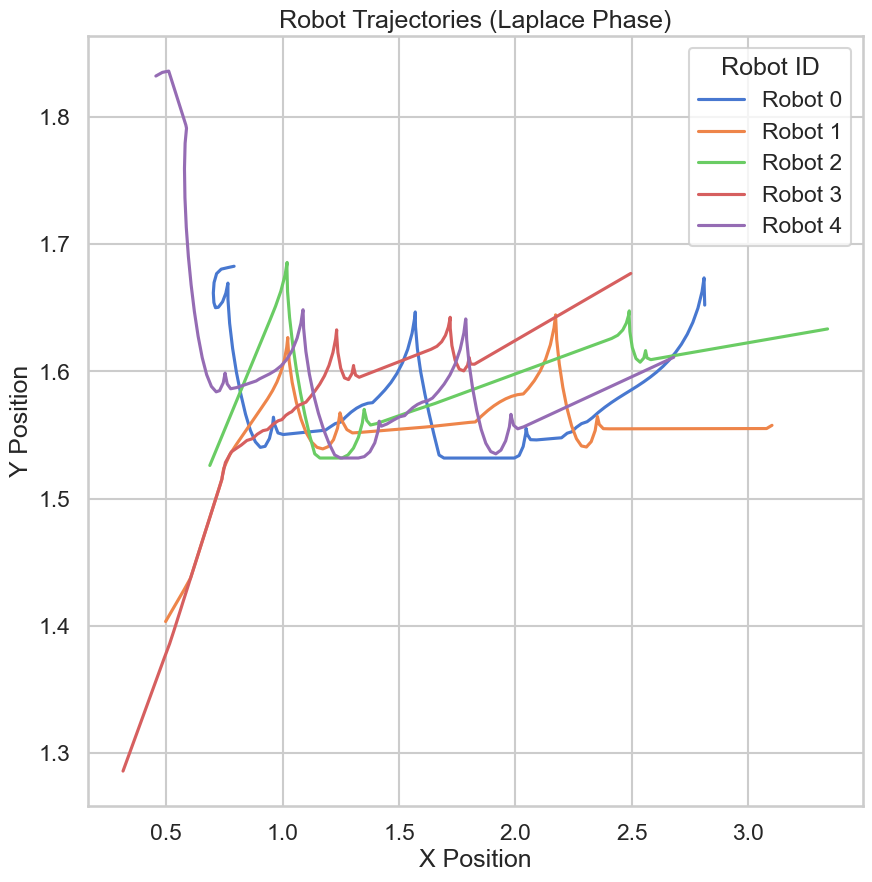

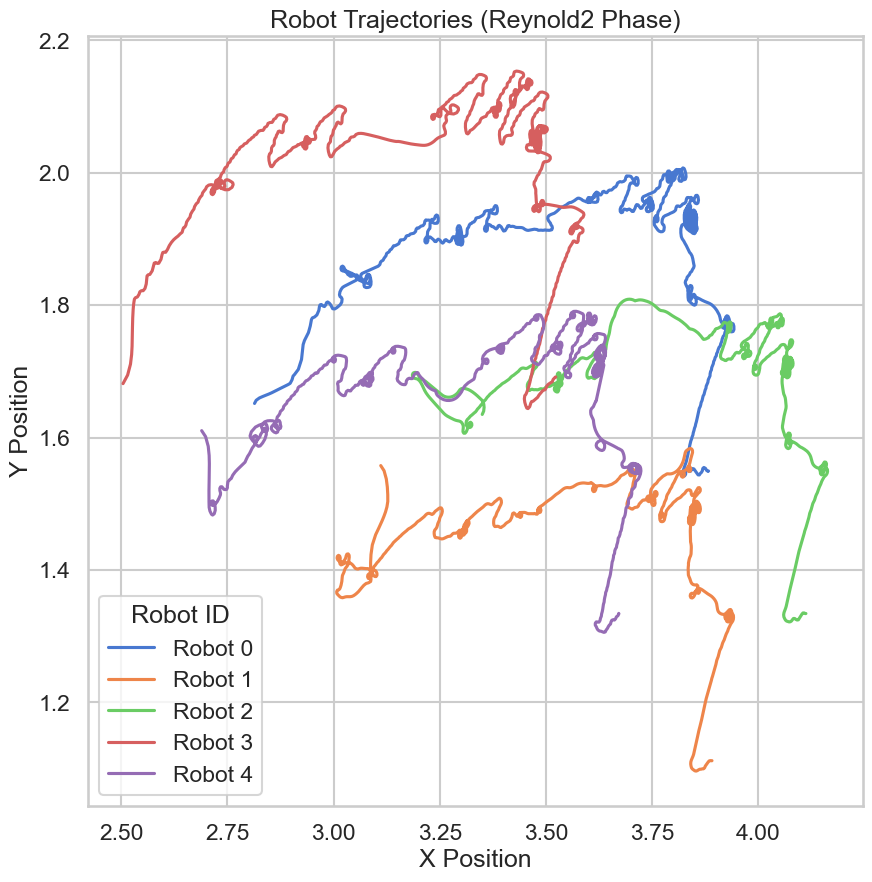

In [63]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV files
reynold1_file = "controllers/super/Reynold1.csv"  # Replace with the path to Reynold1 CSV
reynold2_file = "controllers/super/Reynold2.csv"  # Replace with the path to Reynold2 CSV
laplace_file = "controllers/super/Laplace.csv"    # Replace with the path to Laplace CSV

# Load data from files
reynold1_data = pd.read_csv(reynold1_file)
reynold2_data = pd.read_csv(reynold2_file)
laplace_data = pd.read_csv(laplace_file)

# Rename columns for consistency and better understanding
reynold_columns = ["time", "orientation", "distance", "velocity", "fitness"] + \
                  ["x_robot0", "y_robot0", "x_robot1", "y_robot1", "x_robot2", "y_robot2", 
                   "x_robot3", "y_robot3", "x_robot4", "y_robot4"] + \
                  ["v_robot0", "v_robot1", "v_robot2", "v_robot3", "v_robot4"]
laplace_columns = ["time", "distance", "velocity", "fitness"] + \
                  ["x_robot0", "y_robot0", "x_robot1", "y_robot1", "x_robot2", "y_robot2", 
                   "x_robot3", "y_robot3", "x_robot4", "y_robot4"] + \
                  ["v_robot0", "v_robot1", "v_robot2", "v_robot3", "v_robot4"]

reynold1_data.columns = reynold_columns
reynold2_data.columns = reynold_columns
laplace_data.columns = laplace_columns

# Ensure time is in seconds for clarity
reynold1_data['time'] = reynold1_data['time'] / 1000  # Assuming time was logged in milliseconds
reynold2_data['time'] = reynold2_data['time'] / 1000
laplace_data['time'] = laplace_data['time'] / 1000

# Configure global style for professional plots
sns.set(style="whitegrid", palette="muted", context="talk")

# Define a function to plot metrics from each file
def plot_metrics(data, phase_name, metrics, colors):
    for metric, color in zip(metrics, colors):
        plt.figure(figsize=(8, 6))
        sns.lineplot(x="time", y=metric, data=data, color=color)
        plt.title(f"{metric.capitalize()} Over Time ({phase_name})", fontsize=14)
        plt.xlabel("Time (s)")
        plt.ylabel(metric.capitalize())
        plt.grid(True)
        plt.show()

# Plot metrics for each phase
metrics_reynold = ["orientation", "distance", "velocity", "fitness"]
metrics_laplace = ["distance", "velocity", "fitness"]

# Reynold1 Phase
print("Reynold1 Phase")
plot_metrics(reynold1_data, "Reynold1 Phase", metrics_reynold, ["blue", "green", "orange", "red"])

# Laplace Phase
print("Laplace Phase")
plot_metrics(laplace_data, "Laplace Phase", metrics_laplace, ["green", "orange", "red"])

# Reynold2 Phase
print("Reynold2 Phase")
plot_metrics(reynold2_data, "Reynold2 Phase", metrics_reynold, ["blue", "green", "orange", "red"])

# Define a function to plot trajectories for all robots across all phases
def plot_trajectories(data, phase_name):
    fig, ax = plt.subplots(figsize=(10, 10))
    for i in range(5):  # Iterate through the 5 robots
        ax.plot(
            data[f"x_robot{i}"], 
            data[f"y_robot{i}"], 
            label=f"Robot {i}"
        )
    ax.set_title(f"Robot Trajectories ({phase_name})")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Robot ID")
    plt.grid(True)
    plt.show()

# Plot trajectories for all phases
print("Trajectories")
plot_trajectories(reynold1_data, "Reynold1 Phase")
plot_trajectories(laplace_data, "Laplace Phase")
plot_trajectories(reynold2_data, "Reynold2 Phase")

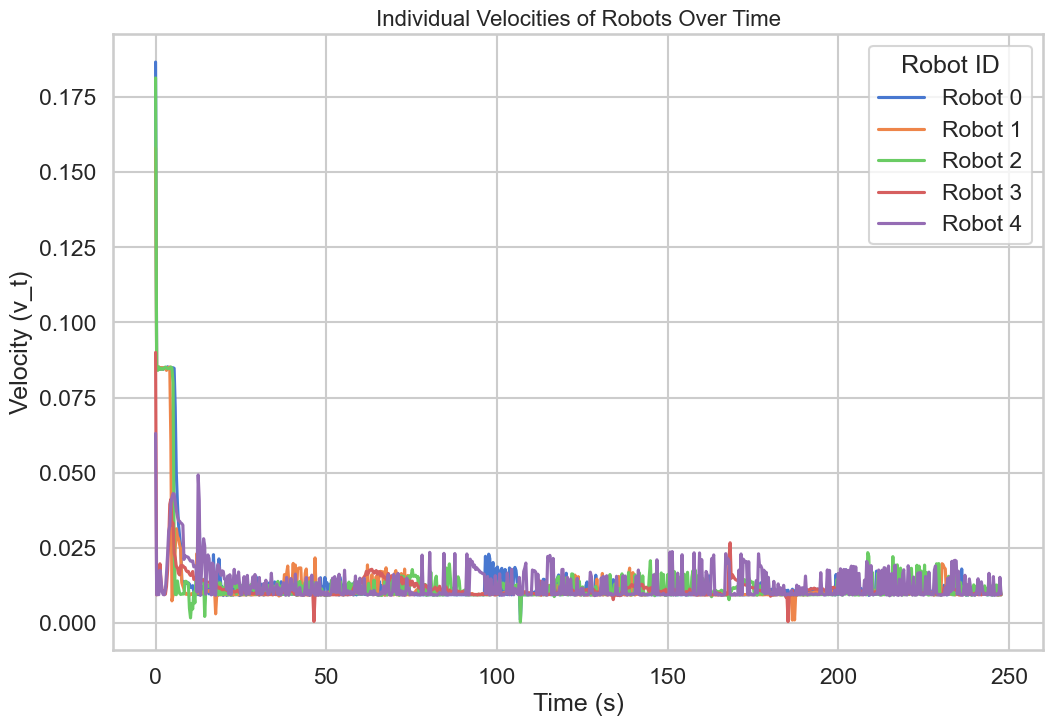

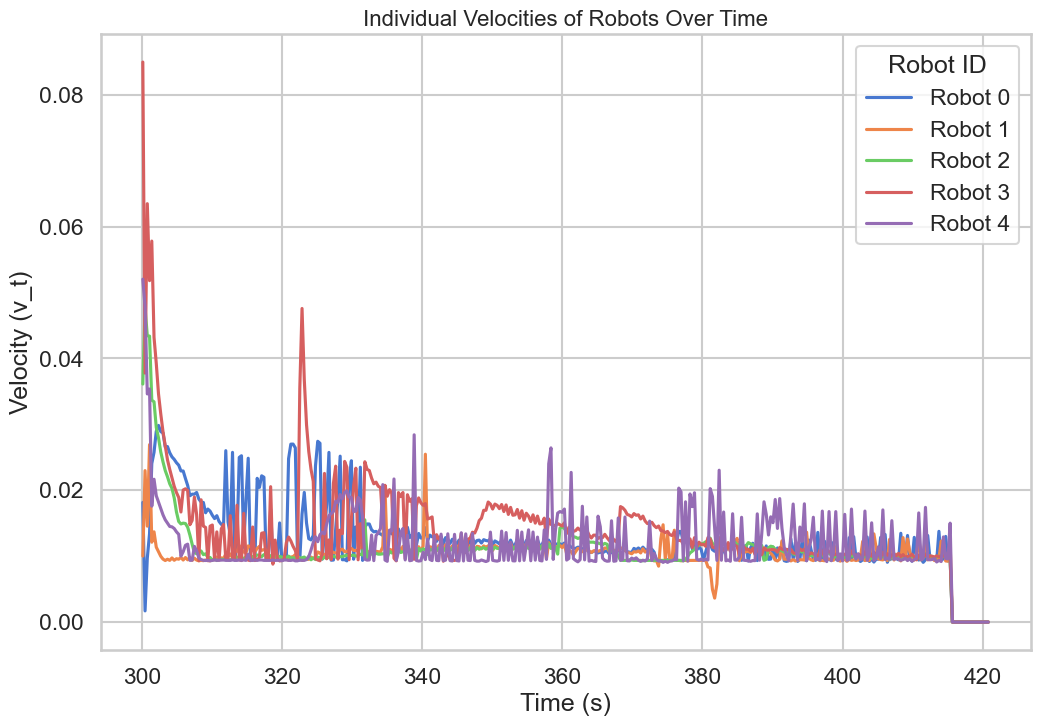

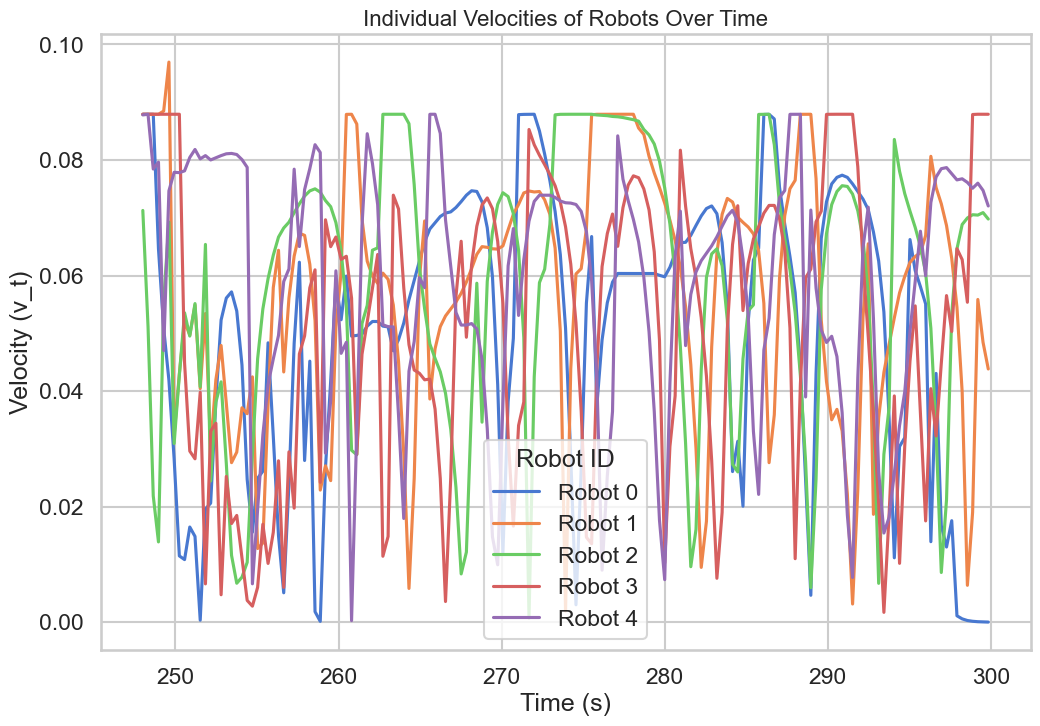

In [48]:
# Plot individual velocities for all robots
def plot_individual_velocities(data):
    plt.figure(figsize=(12, 8))

    # Iterate through each robot and plot their velocity
    for i in range(5):
        sns.lineplot(x="time", y=f"v_robot{i}", data=data, label=f"Robot {i}")

    plt.title("Individual Velocities of Robots Over Time", fontsize=16)
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (v_t)")
    plt.legend(title="Robot ID", loc="best")
    plt.grid(True)
    plt.show()

# Call the function to plot individual velocities
plot_individual_velocities(reynold1_data)
plot_individual_velocities(reynold2_data)
plot_individual_velocities(laplace_data)

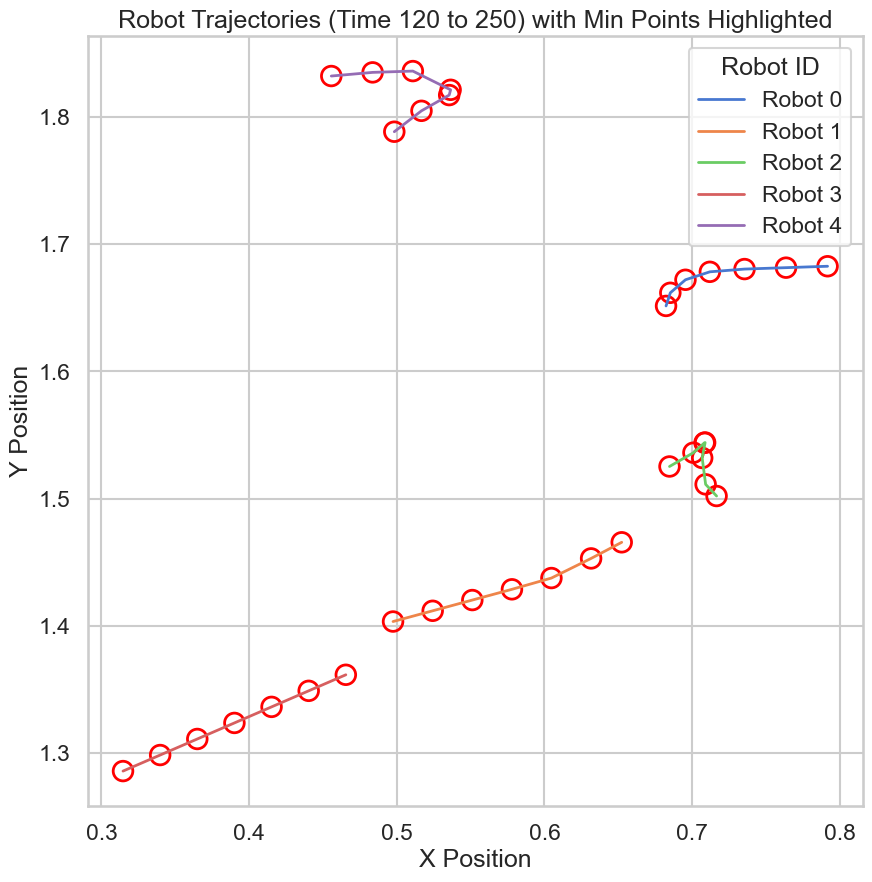

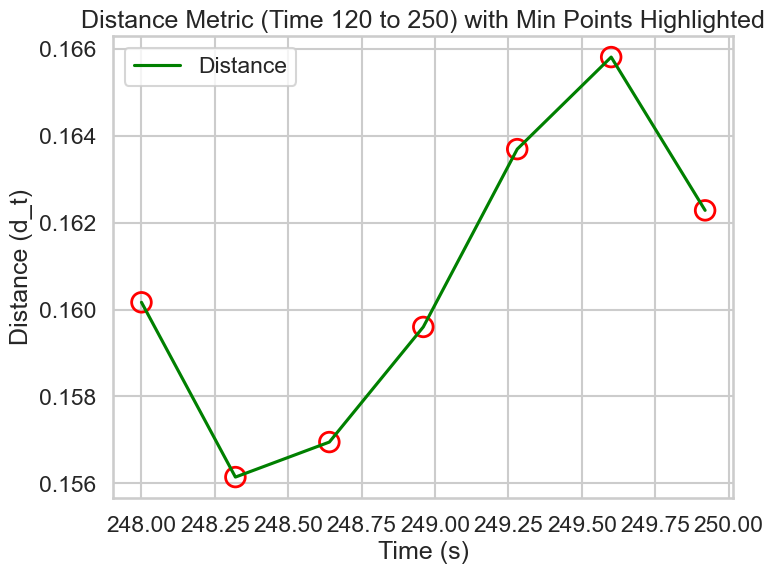

In [49]:
# Plot filtered trajectories with optional circles around minimum 10 points
def plot_filtered_trajectories_with_highlight(data, start_time, end_time, highlight_min_points=True):
    # Filter data for the specified time range
    filtered_data = data[(data["time"] >= start_time) & (data["time"] <= end_time)]

    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot trajectories for only the filtered range
    for i in range(5):  # Iterate through the 5 robots
        ax.plot(
            filtered_data[f"x_robot{i}"], 
            filtered_data[f"y_robot{i}"], 
            label=f"Robot {i}", 
            linewidth=2
        )

        # Highlight minimum 10 points if enabled
        if highlight_min_points:
            min_points_idx = filtered_data[[f"x_robot{i}", f"y_robot{i}"]].apply(
                lambda row: np.linalg.norm(row), axis=1
            ).nsmallest(10).index

            ax.scatter(
                filtered_data.loc[min_points_idx, f"x_robot{i}"], 
                filtered_data.loc[min_points_idx, f"y_robot{i}"], 
                edgecolor="red", 
                facecolor="none", 
                s=200, 
                linewidth=2
            )

    ax.set_title(f"Robot Trajectories (Time {start_time} to {end_time}) with Min Points Highlighted")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Robot ID", loc="best")
    plt.grid(True)
    plt.show()


# Plot filtered distance metric with optional circles around minimum 10 points
def plot_filtered_metrics_with_highlight(data, start_time, end_time, highlight_min_points=True):
    # Filter data for the specified time range
    filtered_data = data[(data["time"] >= start_time) & (data["time"] <= end_time)]

    # Distance Plot
    plt.figure(figsize=(8, 6))
    sns.lineplot(x="time", y="distance", data=filtered_data, color="green", label="Distance")

    # Highlight minimum 10 points if enabled
    if highlight_min_points:
        min_distance_idx = filtered_data["distance"].nsmallest(10).index
        plt.scatter(
            filtered_data.loc[min_distance_idx, "time"], 
            filtered_data.loc[min_distance_idx, "distance"], 
            edgecolor="red", 
            facecolor="none", 
            s=200, 
            linewidth=2
        )

    plt.title(f"Distance Metric (Time {start_time} to {end_time}) with Min Points Highlighted")
    plt.xlabel("Time (s)")
    plt.ylabel("Distance (d_t)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the functions with the optional highlight_min_points parameter
plot_filtered_trajectories_with_highlight(laplace_data, start_time=120, end_time=250, highlight_min_points=True)
plot_filtered_metrics_with_highlight(laplace_data, start_time=120, end_time=250, highlight_min_points=True)


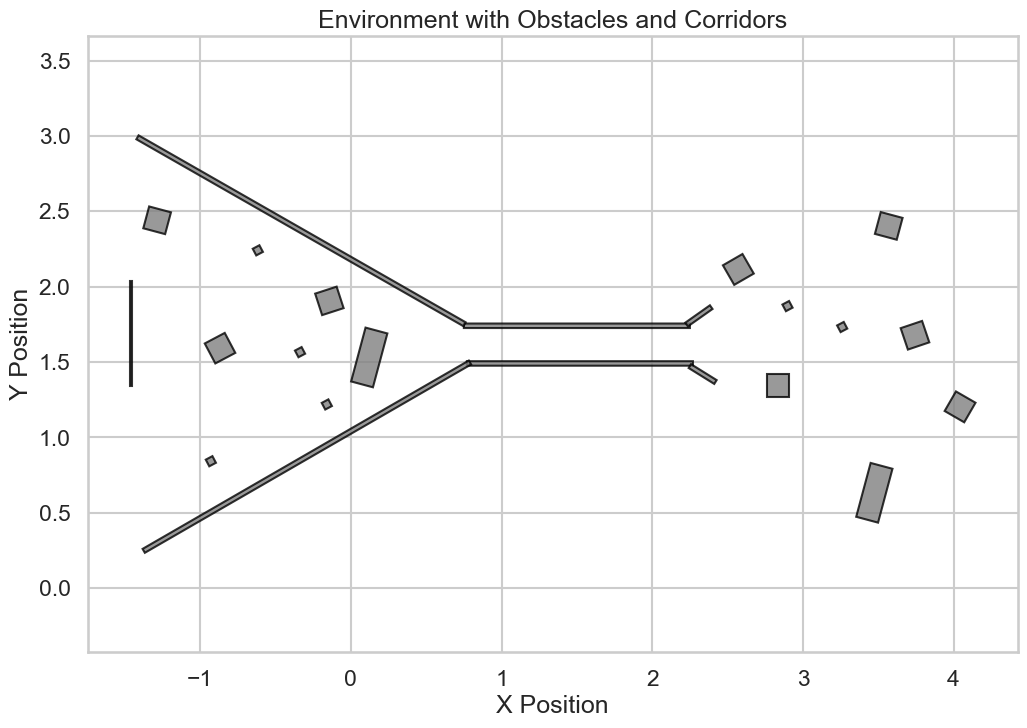

In [56]:
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# File path to the .wbt file
wbt_file = "worlds/topic3.wbt"

# Regex patterns to capture object names, translations, sizes, and rotations
object_pattern = re.compile(r"DEF (\w+) Solid {")
translation_pattern = re.compile(r"translation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
size_pattern = re.compile(r"size ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
rotation_pattern = re.compile(r"rotation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")

# Initialize lists to store obstacle data
obstacles = []

# Parse the .wbt file
with open(wbt_file, 'r') as file:
    lines = file.readlines()

# Extract object names, translations, sizes, and rotations
current_object = None
current_translation = None
current_rotation = None
current_size = None

for line in lines:
    object_match = object_pattern.search(line)
    if object_match:
        current_object = object_match.group(1)
        current_translation = None
        current_rotation = None
        current_size = None
        continue

    if current_object:
        translation_match = translation_pattern.search(line)
        if translation_match:
            current_translation = tuple(map(float, translation_match.groups()))

        rotation_match = rotation_pattern.search(line)
        if rotation_match:
            rotation_axis = tuple(map(float, rotation_match.groups()[:3]))
            current_rotation = float(rotation_match.group(4))  # Extract rotation angle in radians
            
            # Adjust the angle only for specific cases
            if current_object == "Corridor_3" and rotation_axis == (0.0, 0.0, -1.0):
                current_rotation -= 1.04281  # Subtract the specified value
            
            if current_object == "Corridor_2":
                current_rotation += 1.8

            if current_object == "Corridor_1":
                current_rotation += 1.4

        size_match = size_pattern.search(line)
        if size_match:
            current_size = tuple(map(float, size_match.groups()))

        # If all necessary data is gathered, append the obstacle
        if current_translation and current_size:
            rotation_angle = current_rotation if current_rotation is not None else 0
            obstacles.append({
                "name": current_object,
                "translation": current_translation,
                "size": current_size,
                "rotation": rotation_angle
            })
            current_object = None  # Reset for next object

# Remove migration target or irrelevant objects
obstacles = [obs for obs in obstacles if "migration_target" not in obs["name"]]

# Function to calculate rotated rectangle corners
def calculate_corners(center, size, rotation):
    cx, cy = center
    width, height = size[0], size[1]
    corners = [
        [-width / 2, -height / 2],
        [width / 2, -height / 2],
        [width / 2, height / 2],
        [-width / 2, height / 2],
    ]
    # Rotate corners
    rotated_corners = [
        [
            cx + corner[0] * np.cos(rotation) - corner[1] * np.sin(rotation),
            cy + corner[0] * np.sin(rotation) + corner[1] * np.cos(rotation),
        ]
        for corner in corners
    ]
    return rotated_corners

# Function to plot obstacles and corridors
def plot_obstacles(obstacles):
    fig, ax = plt.subplots(figsize=(12, 8))

    for obstacle in obstacles:
        x, y, z = obstacle["translation"]
        width, height, depth = obstacle["size"]
        rotation = obstacle["rotation"]

        # Calculate rotated rectangle corners
        corners = calculate_corners((x, y), (width, height), rotation)

        # Draw polygon for obstacle
        polygon = Polygon(corners, closed=True, edgecolor="black", facecolor="gray", alpha=0.8)
        ax.add_patch(polygon)

    ax.set_title("Environment with Obstacles and Corridors")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

# Call the function to plot
plot_obstacles(obstacles)


# Merged the Obstacle map with the trajectories

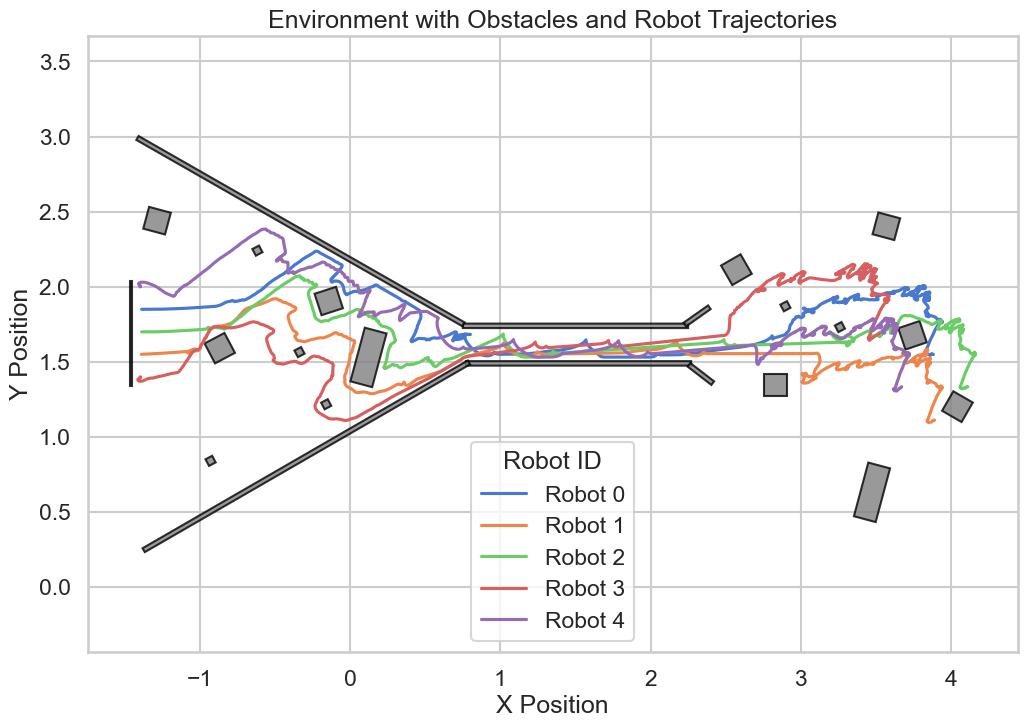

In [65]:
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import pandas as pd
import seaborn as sns

# File paths
wbt_file = "worlds/topic3.wbt"
csv_file = "controllers/super/full_data.csv"

# Load CSV file
data = pd.read_csv(csv_file)

# Rename columns for better understanding
data.columns = ["time", "orientation", "distance", "velocity", "fitness"] + \
               ["x_robot0", "y_robot0", "x_robot1", "y_robot1", "x_robot2", "y_robot2"] + \
               ["x_robot3", "y_robot3", "x_robot4", "y_robot4", "v_robot0", "v_robot1", "v_robot2", "v_robot3", "v_robot4"]

# Ensure time is in seconds for clarity
data['time'] = data['time'] / 1000  # Assuming time was logged in milliseconds

# Regex patterns to capture object names, translations, sizes, and rotations
object_pattern = re.compile(r"DEF (\w+) Solid {")
translation_pattern = re.compile(r"translation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
size_pattern = re.compile(r"size ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")
rotation_pattern = re.compile(r"rotation ([\d\-.]+) ([\d\-.]+) ([\d\-.]+) ([\d\-.]+)")

# Initialize lists to store obstacle data
obstacles = []

# Parse the .wbt file
with open(wbt_file, 'r') as file:
    lines = file.readlines()

# Extract object names, translations, sizes, and rotations
current_object = None
current_translation = None
current_rotation = None
current_size = None

for line in lines:
    object_match = object_pattern.search(line)
    if object_match:
        current_object = object_match.group(1)
        current_translation = None
        current_rotation = None
        current_size = None
        continue

    if current_object:
        translation_match = translation_pattern.search(line)
        if translation_match:
            current_translation = tuple(map(float, translation_match.groups()))

        rotation_match = rotation_pattern.search(line)
        if rotation_match:
            rotation_axis = tuple(map(float, rotation_match.groups()[:3]))
            current_rotation = float(rotation_match.group(4))  # Extract rotation angle in radians
            
            # Adjust the angle only for specific cases
            if current_object == "Corridor_3" and rotation_axis == (0.0, 0.0, -1.0):
                current_rotation -= 1.04281  # Subtract the specified value
            
            if current_object == "Corridor_2":
                current_rotation += 1.7

            if current_object == "Corridor_1":
                current_rotation += 1.4

        size_match = size_pattern.search(line)
        if size_match:
            current_size = tuple(map(float, size_match.groups()))

        # If all necessary data is gathered, append the obstacle
        if current_translation and current_size:
            rotation_angle = current_rotation if current_rotation is not None else 0
            obstacles.append({
                "name": current_object,
                "translation": current_translation,
                "size": current_size,
                "rotation": rotation_angle
            })
            current_object = None  # Reset for next object

# Remove migration target or irrelevant objects
obstacles = [obs for obs in obstacles if "migration_target" not in obs["name"]]

# Function to calculate rotated rectangle corners
def calculate_corners(center, size, rotation):
    cx, cy = center
    width, height = size[0], size[1]
    corners = [
        [-width / 2, -height / 2],
        [width / 2, -height / 2],
        [width / 2, height / 2],
        [-width / 2, height / 2],
    ]
    # Rotate corners
    rotated_corners = [
        [
            cx + corner[0] * np.cos(rotation) - corner[1] * np.sin(rotation),
            cy + corner[0] * np.sin(rotation) + corner[1] * np.cos(rotation),
        ]
        for corner in corners
    ]
    return rotated_corners

# Function to plot obstacles and robot trajectories
def plot_environment_with_trajectories(obstacles, data):
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot obstacles
    for obstacle in obstacles:
        x, y, z = obstacle["translation"]
        width, height, depth = obstacle["size"]
        rotation = obstacle["rotation"]

        # Calculate rotated rectangle corners
        corners = calculate_corners((x, y), (width, height), rotation)

        # Draw polygon for obstacle
        polygon = Polygon(corners, closed=True, edgecolor="black", facecolor="gray", alpha=0.8)
        ax.add_patch(polygon)

    # Plot trajectories
    for i in range(5):  # Iterate through the 5 robots
        ax.plot(
            data[f"x_robot{i}"], 
            data[f"y_robot{i}"], 
            label=f"Robot {i}"
        )

    ax.set_title("Environment with Obstacles and Robot Trajectories")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.legend(title="Robot ID")
    plt.grid(True)  # Add grid for better visualization
    plt.axis("equal")  # Keep aspect ratio equal for better spatial representation
    plt.show()

# Call the function to plot
plot_environment_with_trajectories(obstacles, data)
